In [5]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "statsmodels==0.14.6" "prophet==1.3.0"

import os, json, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from prophet import Prophet
import warnings; warnings.filterwarnings("ignore")
import cmdstanpy; cmdstanpy.utils.get_logger().disabled = True   # 적합 때마다 찍히는 진행 로그를 숨긴다
logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)
logging.getLogger("prophet").setLevel(logging.WARNING)

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  등록해야 이름이 보인다(등록하지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 베이스라인=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def rmse(a, b):
    """두 계열의 평균 제곱근 오차 — ML 수업에서 쓰던 그 지표 그대로"""
    return float(np.sqrt(np.mean((np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) ** 2)))

print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

사용 폰트: DejaVu Sans | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


In [6]:
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

## 평균이 한 방향으로 옮겨 가는 일 매출에는 어떤 차분을 할까요?
예를 들어 어느 매장 일 매출 365일이 1년 내내 꾸준히 는다고 합시다. ADF 는 단위근 가설을 기각하지 못했고, KPSS 는 정상 가설을 기각했습니다. 자기상관은 시차 7·14·21 에서 다시 커지지 않고 모든 시차에서 느리게 감소합니다.
핵심 키워드: 두 검정의 기각 방향, 느리게 감소하는 자기상관, 1차 차분 1회

A. 1차 차분을 1회한다.

사유: 우선 해당 데이터는 1년 내내 꾸준히 증가하는 추세를 가지고 있고 단위근이 있는 것으로 추측되었는데
ADF 귀무가설 기각하지 못하여 이를 뒷받침하는 근거였고 KPSS도 귀무가설을 기각하여 비정상성에 해당하는 것으로 확인되었음.
그러면서 자기상관이 시차 7, 14, 21에서 다시 커지지 않고 모든 시차에서 느리게 감소하기 때문에 계절 차분 보다는 레벨 차분을 통해서 정상성을 만들어 주는 것이 적절하다고 생각하였다.

## 세 후보의 AIC 로 공식 차수를 고른다면 무엇일까요?
예를 들어 첫날 결론이 d = 0 인 계열에서 후보 셋의 AIC 를 구했다고 합시다. (1,0,1) 2,000.4 · (2,0,2) 1,999.1 · (1,1,1) 1,950.2 입니다. 핵심 키워드: 같은 d 끼리만 비교, 차이 2 이하는 항이 적은 쪽, 1위와 2위의 차이

A. (1,1,1) 세 후보 가운데 AIC가 가장 낮다.

사유: 첫날 결론이 d=0이라고 했다지만 세 후보 사이에선 d = 1을 했던 후보가 AIC 1950.2로 가장 낮기 때문에 공식 차수로서 적절해 보인다.

답: C. (1,0,1): d = 0 인 두 후보의 차이가 2 이하라 항이 적다

## 금요일 23시에 168시간을 예측하는 베이스라인은 어느 코드로 만들까요?
예를 들어 금요일 23시까지의 실측만 보고 다음 168시간의 시간당 대여 수를 예측하는 베이스라인을 만든다고 합시다. 핵심 키워드: 원점 전 값만 쓰는 베이스라인, 원점 뒤 실측, 계절 나이브 168

B. df["demand"].shift(168): 1주일 전 같은 시각 값

사유: 다음 168시간의 시간당 대여 수를 예측하는 것이기 때문에 베이스라인은 계절 나이브 168로 설정하는 B로 선택하였습니다.

## 백분율 오차를 한 수로 적을 때 무엇을 쓸까요?
예를 들어 3시 실측 10대를 20대로, 18시 실측 1,000대를 1,300대로 예측했다고 합시다. 핵심 키워드: 실측으로 나누는 MAPE, 합으로 나누는 WAPE, 대표 지표 RMSE

A. MAPE 65%: 두 시각의 오차 비율 100% 와 30% 의 평균

사유: 백분율의 오차 즉 오차 비율을 확인하는 지표인 MAPE로 확인해야하고 두 시각의 오차 비율에 따라 65%이다.

답: C. WAPE 약 31%: 오차 절댓값의 합 310대 ÷ 실측의 합 1,010대

## 원점 5개에서 베이스라인보다 낮게 나온 Prophet 구성은 어떻게 할까요?
예를 들어 조건부 계절성을 둔 Prophet 의 원점 5개 평균 RMSE 가 계절 나이브 168 보다 약 3% 낮다고 합시다. 11월 24～30일 테스트 구간은 아직 쓰지 않았습니다. 핵심 키워드: 테스트 구간은 한 번, 여러 후보의 최솟값, 정하기 전 운영 예측은 베이스라인

B. 떼어 둔 테스트 구간에서 한 번 채점한 뒤 정한다

사유: 우선 바로 RMSE가 낮은 모델을 채택하기 보다는 떼어 둔 테스트 구간과 비교하여 예측 오차가 어느정도인지 확인이 필요할 것 같다. 더불어 C 같은 경우는 테스트 데이터를 학습에 포함시키는 누수의 리스크가 있기 때문에 B가 적절해 보임.

표 1 · 단순 예측 셋의 예측 원점 5개 RMSE (대)
           계절 나이브 168  계절 나이브 24  시각별 평균
10-19 23시      306.52     398.25  345.51
10-26 23시      418.18     539.28  403.57
11-02 23시      457.07     502.95  516.89
11-09 23시      430.72     318.52  320.53
11-16 23시      205.25     271.23  403.89
원점 5개 평균       363.55     406.05  398.08


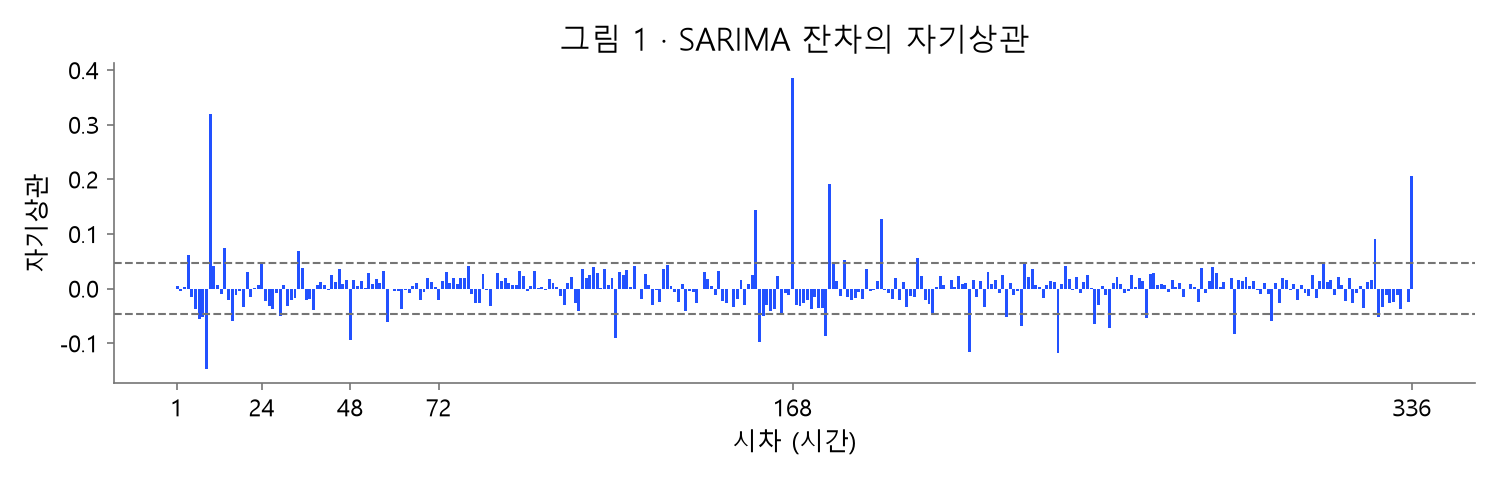

표 2 · SARIMA 잔차 진단 (잔차 1,824개)
  경계선 ±0.046 · 시차 1～336 가운데 경계선 밖 36개
  자기상관이 큰 시차 셋: 168 (0.386) · 10 (0.320) · 336 (0.206)
  시차 1 · 24 의 자기상관: 0.004 · 0.045
  Ljung-Box p 값: 시차 24 3.2e-47 · 시차 168 1.2e-88
표 3 · SARIMA 예측구간이 담은 검증 168시간 (시간)
        담은 시각  상한 위  하한 아래  실제 포함률(%)
명목 95%    162     0      6       96.4
명목 80%    137     0     31       81.5
  검증 168시간 평균: 실측 694.2대 · 점 예측 965.6대
표 4 · 학습 구간과 검증 구간의 기온 (°C)
  학습 1,848시간: 평균 15.8 · 5백분위수 6.2 · 최저 0.8
  검증 168시간: 평균 4.9 · 최저 -3.0
  검증 168시간 가운데 학습 5백분위수보다 추운 시각 101시간
  검증 168시간 가운데 학습 최저보다 추운 시각 23시간
표 5 · 기준 구간 시각별 잔차 중앙값과 MAD (대)
  기준 구간 10월 20일～11월 16일 · 라벨 없는 잔차 599시각
     잔차 중앙값  MAD
0시      -27   84
4시       -4   13
8시      -86  142
13시     -74  175
18시    -301  386


In [7]:
# 오늘의 준비 — 읽고 실행만 합니다
# 서울 공유자전거로 표 1～5 와 그림 1 을 만듭니다. SARIMA 를 한 번 적합해 10～20초 걸립니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일창에 올린 뒤
#  URL 값으로 파일 이름 "seoul+bike+sharing+demand.zip" 을 적으세요
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                                                 # 등간격 1시간
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))    # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(168))                                       # 1주일 전 같은 시각 값으로 채운다
df["demand"] = _y.fillna(_y.shift(-168))                            # 1주일 전도 휴무면 1주일 뒤 값으로
train = df.loc["2018-09-01 00:00":"2018-11-16 23:00"]              # 학습 1,848시간
valid = df.loc["2018-11-17 00:00":"2018-11-23 23:00"]              # 검증 168시간

# 표 1: 단순 예측 셋을 예측 원점 5개(금요일 23시)에서 168시간씩 채점한다
ORIGINS = pd.date_range("2018-10-19 23:00", "2018-11-16 23:00", freq="7D")
dem_all = df["demand"].astype(float)
origin_rows = {}
for o in ORIGINS:
    week = pd.date_range(o + pd.Timedelta(hours=1), periods=168, freq="h")   # 원점 1시간 뒤부터 168시간
    last_day = dem_all.loc[o - pd.Timedelta(hours=23):o].to_numpy()          # 원점 전 마지막 하루 24시각
    fit_part = dem_all.loc["2018-09-01 00:00":o]
    hour_mean = fit_part.groupby(fit_part.index.hour).mean()                  # 9월 1일～원점의 시각별 평균
    origin_rows[f"{o:%m-%d} 23시"] = {
        "계절 나이브 168": rmse(dem_all.loc[week], dem_all.shift(168).loc[week]),
        "계절 나이브 24": rmse(dem_all.loc[week], np.tile(last_day, 7)),
        "시각별 평균": rmse(dem_all.loc[week], hour_mean.loc[week.hour].to_numpy())}
origin_rmse = pd.DataFrame(origin_rows).T
origin_rmse.loc["원점 5개 평균"] = origin_rmse.mean()
print("표 1 · 단순 예측 셋의 예측 원점 5개 RMSE (대)")
print(origin_rmse.round(2).to_string())

# 그림 1 · 표 2: 학습 1,848시간에 셋째 날 SARIMA 를 적합하고 잔차를 진단한다
sarima_res = SARIMAX(train["demand"], order=(1, 0, 1), seasonal_order=(1, 1, 1, 24)).fit(disp=False)
sarima_resid = sarima_res.resid.iloc[24:]                          # 앞 24시각은 계절차분 초기값이라 뺀다
resid_acf = acf(sarima_resid, nlags=336)
acf_bound = 1.96 / np.sqrt(len(sarima_resid))
resid_top3 = (np.argsort(-np.abs(resid_acf[1:]))[:3] + 1).tolist()  # 절댓값이 큰 시차 셋
lb_p = acorr_ljungbox(sarima_resid, lags=[24, 168], model_df=4)["lb_pvalue"].to_numpy()
fig, ax = plt.subplots(figsize=(FIG_W, 3.2))
ax.bar(range(1, 337), resid_acf[1:], width=0.8, color=COL["파랑"])
ax.axhline(acf_bound, color=COL["회색"], ls="--", lw=1)
ax.axhline(-acf_bound, color=COL["회색"], ls="--", lw=1)
ax.set_xticks([1, 24, 48, 72, 168, 336])
ax.set_title("그림 1 · SARIMA 잔차의 자기상관")
ax.set_xlabel("시차 (시간)")
ax.set_ylabel("자기상관")
plt.show()
print("표 2 · SARIMA 잔차 진단 (잔차 1,824개)")
print(f"  경계선 ±{acf_bound:.3f} · 시차 1～336 가운데 경계선 밖 {int((np.abs(resid_acf[1:]) > acf_bound).sum())}개")
print("  자기상관이 큰 시차 셋: " + " · ".join(f"{k} ({resid_acf[k]:.3f})" for k in resid_top3))
print(f"  시차 1 · 24 의 자기상관: {resid_acf[1]:.3f} · {resid_acf[24]:.3f}")
print(f"  Ljung-Box p 값: 시차 24 {lb_p[0]:.1e} · 시차 168 {lb_p[1]:.1e}")

# 표 3: 같은 SARIMA 로 검증 168시간을 한 번에 예측하고 예측구간이 실측을 몇 시각 담았는지 센다
sarima_fc = sarima_res.get_forecast(steps=len(valid))
valid_act = valid["demand"].to_numpy()
cover_rows = {}
for nominal, alpha in [("명목 95%", 0.05), ("명목 80%", 0.20)]:       # alpha 는 유의수준, 명목 포함률 = 1 − alpha
    ci = sarima_fc.conf_int(alpha=alpha)
    lo, hi = ci.iloc[:, 0].to_numpy(), ci.iloc[:, 1].to_numpy()
    n_in = int(((valid_act >= lo) & (valid_act <= hi)).sum())
    cover_rows[nominal] = {"담은 시각": n_in, "상한 위": int((valid_act > hi).sum()),
                           "하한 아래": int((valid_act < lo).sum()),
                           "실제 포함률(%)": round(100 * n_in / len(valid_act), 1)}
cover_table = pd.DataFrame.from_dict(cover_rows, orient="index")   # 행 = 명목 포함률
pred_mean = float(sarima_fc.predicted_mean.mean())
print("표 3 · SARIMA 예측구간이 담은 검증 168시간 (시간)")
print(cover_table.to_string())
print(f"  검증 168시간 평균: 실측 {valid_act.mean():.1f}대 · 점 예측 {pred_mean:.1f}대")

# 표 4: 검증 168시간의 기온이 학습 1,848시간 기온 범위 안인지 본다
temp_train = train["temp"].astype(float)
temp_valid = valid["temp"].astype(float)
temp_p5 = float(np.percentile(temp_train, 5))                      # 학습 기온의 5백분위수
n_cold = int((temp_valid < temp_p5).sum())
n_below_min = int((temp_valid < temp_train.min()).sum())
print("표 4 · 학습 구간과 검증 구간의 기온 (°C)")
print(f"  학습 1,848시간: 평균 {temp_train.mean():.1f} · 5백분위수 {temp_p5:.1f} · 최저 {temp_train.min():.1f}")
print(f"  검증 168시간: 평균 {temp_valid.mean():.1f} · 최저 {temp_valid.min():.1f}")
print(f"  검증 168시간 가운데 학습 5백분위수보다 추운 시각 {n_cold}시간")
print(f"  검증 168시간 가운데 학습 최저보다 추운 시각 {n_below_min}시간")

# 표 5: 기준 구간(10월 20일～11월 16일)의 라벨 없는 잔차로 시각별 중앙값과 MAD 를 구한다
resid_base = df["count"].astype(float) - dem_all.shift(168)        # 잔차 = 실측 − 1주일 전 보정 수요
label_hour = df["functioning"].eq("No") | (df["rain"].astype(float) >= 10)   # 정답 라벨: 휴무 · 시간당 강수 10mm 이상
in_base = pd.Series((df.index >= pd.Timestamp("2018-10-20 00:00"))
                    & (df.index <= pd.Timestamp("2018-11-16 23:00")), index=df.index)
base_part = pd.DataFrame({"r": resid_base, "h": df.index.hour}, index=df.index)[
    in_base & ~label_hour & resid_base.notna()]
med_by_hour = base_part.groupby("h")["r"].median()                  # 시각별 잔차 중앙값 24개
mad_by_hour = base_part.groupby("h")["r"].apply(lambda s: float(np.median(np.abs(s - s.median()))))
hour_table = pd.DataFrame({"잔차 중앙값": med_by_hour, "MAD": mad_by_hour}).loc[[0, 4, 8, 13, 18]]
hour_table.index = [f"{h}시" for h in hour_table.index]
print("표 5 · 기준 구간 시각별 잔차 중앙값과 MAD (대)")
print(f"  기준 구간 10월 20일～11월 16일 · 라벨 없는 잔차 {len(base_part)}시각")
print(hour_table.round(0).astype(int).to_string())

## SARIMA 잔차에 남은 규칙
「오늘의 준비」 셀을 실행하면 나오는 「그림 1 · SARIMA 잔차의 자기상관」과 「표 2 · SARIMA 잔차 진단」을 봅니다. 두 출력으로 어떤 결론을 적을까요? 핵심 키워드: 시차 168 잔차 자기상관, p 값이 작으면 규칙이 남았다, 계절 주기 하나인 SARIMA

B. 1주일 전 같은 시각과의 관계가 남았다. SARIMA 의 한계로 적는다

## SARIMA 80% 예측구간을 적는 법
「오늘의 준비」 셀을 실행하면 나오는 「표 3 · SARIMA 예측구간이 담은 검증 168시간 (시간)」을 봅니다. 80% 예측구간을 보고서에 어떻게 적을까요? 핵심 키워드: 벗어난 방향, 예측선의 치우침, 명목 포함률과 실제 포함률

C. 벗어난 시각이 모두 하한 아래라 예측선이 높다. 구간은 참고로만 적는다

## 기온을 외생 변수로 더하기 전에
「오늘의 준비」 셀을 실행하면 나오는 「표 4 · 학습 구간과 검증 구간의 기온 (°C)」를 봅니다. 다음 주 예측에 기온을 외생 변수로 더해도 될까요? 핵심 키워드: 학습 범위 밖의 외생 변수, 5백분위수, 검증 오차로 정하기

A. 바로 더하지 않는다. 학습에서 드문 기온이 많아 검증 오차로 먼저 확인한다

## 같은 잔차가 이상으로 탐지되는 시각
「오늘의 준비」 셀을 실행하면 나오는 「표 5 · 기준 구간 시각별 잔차 중앙값과 MAD (대)」를 봅니다. 예를 들어 4시·8시·18시의 잔차가 모두 −150대라면 임계값 3.5 에서 이상으로 탐지되는 시각은? 핵심 키워드: 시각별 중앙값과 MAD, 새벽의 작은 MAD, 이상으로 탐지된 시각의 실측과 예측

A. 18시만

잔차 강건 Z 는 잔차의 크기가 아니라, 그 시각의 평소 잔차에서 평소 오르내림의 몇 배 벗어났는지를 나타냅니다. 식은 0.6745 × (잔차 − 그 시각 중앙값) ÷ 그 시각 MAD 입니다. 표 5 에서 4시는 중앙값 −4대, MAD 13대라 강건 Z 가 0.6745 × (−150 + 4) ÷ 13 ≈ −7.6 입니다. 절댓값이 3.5 를 넘어 이상으로 탐지됩니다. 8시는 0.6745 × (−150 + 86) ÷ 142 ≈ −0.3 입니다. 18시는 평소 잔차가 −301대라 −150대는 오히려 평소보다 덜 모자란 값이고, 강건 Z 는 약 +0.3 입니다. 첫째 보기는 평소 모자람이 큰 18시를 이상으로 본 것입니다. 셋째 보기는 −150대라는 잔차 크기만 본 것입니다. 넷째 보기는 150대를 어느 시각에서나 작은 차이로 본 것입니다. 새벽은 MAD 가 작아 작은 차이도 이상으로 탐지됩니다. 이상 열은 실측이 들어오는 대로 채우고, 이상으로 탐지된 시각에는 실측과 예측 대수를 함께 적습니다. 임계값은 계획표 168시각에서 이상으로 탐지된 시각 수가 아니라 기준 구간의 하루 오탐 수로 고릅니다.

In [10]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 이름을 직접 만듭니다

_missing = [_n for _n in ("pd", "np", "plt", "datefmt") if _n not in globals()]
if _missing:                                                       # 맨 위 설치 셀을 아직 실행하지 않았습니다
    raise NameError("맨 위 설치 셀을 먼저 실행하세요 — 아직 없는 이름 "
                    + " · ".join(_missing))
if "judge" not in globals():                                       # 막지는 않고 알리기만 합니다
    print("ⓘ 맨 위 [채점] 셀을 아직 실행하지 않았습니다 — 그 셀을 한 번 실행해야"
          " 「PROMPT 셀」 아래에 채점 결과와 힌트가 나옵니다")

URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"
_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무 295시간은 결측으로 본다
_y = _s.fillna(_s.shift(24 * 7))
df["demand"] = _y.fillna(_y.shift(-24 * 7))                       # 1주일 전후 같은 시각으로 보정

TRAIN_END = "2018-11-16 23:00"                                    # 예측 원점: 이 시각까지의 실측만 씁니다
BASE_START = "2018-10-20 00:00"                                   # 기준 구간의 시작: 원점까지 마지막 4주
valid = df.loc["2018-11-17 00:00":"2018-11-23 23:00"]             # 다음 주 168시각 = 계획표의 행
plan = pd.DataFrame(index=valid.index)
plan.index.name = "시각"

# 여섯째 날 레퍼런스가 잔차의 실측으로 쓰는 원본 대여 수 count (계획표 168시각은 휴무가 없어 보정 수요와 같다)
CNT = df["count"].astype(float)
DEM = df["demand"].astype(float)                                  # 기댓값을 만들 보정 수요
HOUR = pd.Series(df.index.hour, index=df.index)
LABEL = df["functioning"].eq("No") | (df["rain"].astype(float) >= 10)   # 정답 라벨: 휴무 · 시간당 강수 10mm 이상
IN_BASE = pd.Series((df.index >= pd.Timestamp(BASE_START))
                    & (df.index <= pd.Timestamp(TRAIN_END)), index=df.index)
RESID = CNT - DEM.shift(168)                                       # 잔차 = 실측 − 1주일 전 같은 시각의 보정 수요
_base = pd.DataFrame({"r": RESID, "h": HOUR})[IN_BASE & ~LABEL & RESID.notna()]
_g = _base.groupby("h")["r"]
MED_H = _g.median()                                                # 기준 구간의 시각별 잔차 중앙값 24개
MAD_H = _g.apply(lambda s: float(np.median(np.abs(s - s.median()))))   # 기준 구간의 시각별 MAD 24개
ALERTS = (3.5, 4, 5)                                               # 비교할 임계값 3개

# 본문이 인용하는 수를 확인합니다
_n_base = int(IN_BASE.sum())
assert _n_base == 672 and len(_base) == 599 and len(plan) == 168
assert MAD_H[0] == 84 and MAD_H[4] == 13 and MED_H[8] == -86 and MAD_H[8] == 142
assert (CNT.loc[plan.index] == DEM.loc[plan.index]).all()
assert DEM.shift(168).loc[pd.Timestamp("2018-11-17 00:00")] == 754

print(f"기준 구간 : {BASE_START[:10]} 0시 ~ {TRAIN_END[:10]} 23시 · {_n_base}시간 · {_n_base // 24}일")
print(f"라벨 없는 기준 구간 잔차 : {len(_base)}시간 → 시각별 중앙값 MED_H · MAD MAD_H 24개씩")
print(f"계획표 plan : {plan.index[0]:%m-%d %H}시 ~ {plan.index[-1]:%m-%d %H}시 · 아직 열 없음")
print("쓸 수 있는 이름 : plan · CNT · DEM · RESID · HOUR · LABEL · IN_BASE"
      " · MED_H · MAD_H · ALERTS · datefmt")

ⓘ 맨 위 [채점] 셀을 아직 실행하지 않았습니다 — 그 셀을 한 번 실행해야 「PROMPT 셀」 아래에 채점 결과와 힌트가 나옵니다
기준 구간 : 2018-10-20 0시 ~ 2018-11-16 23시 · 672시간 · 28일
라벨 없는 기준 구간 잔차 : 599시간 → 시각별 중앙값 MED_H · MAD MAD_H 24개씩
계획표 plan : 11-17 00시 ~ 11-23 23시 · 아직 열 없음
쓸 수 있는 이름 : plan · CNT · DEM · RESID · HOUR · LABEL · IN_BASE · MED_H · MAD_H · ALERTS · datefmt


임계값 3.5 에서 기준 구간 하루 오탐 수 = 2.43 건
임계값 4 에서 기준 구간 하루 오탐 수 = 1.64 건
임계값 5 에서 기준 구간 하루 오탐 수 = 0.75 건
선택한 임계값 ALERT = 4 (하루 오탐 상한 2건 기준)


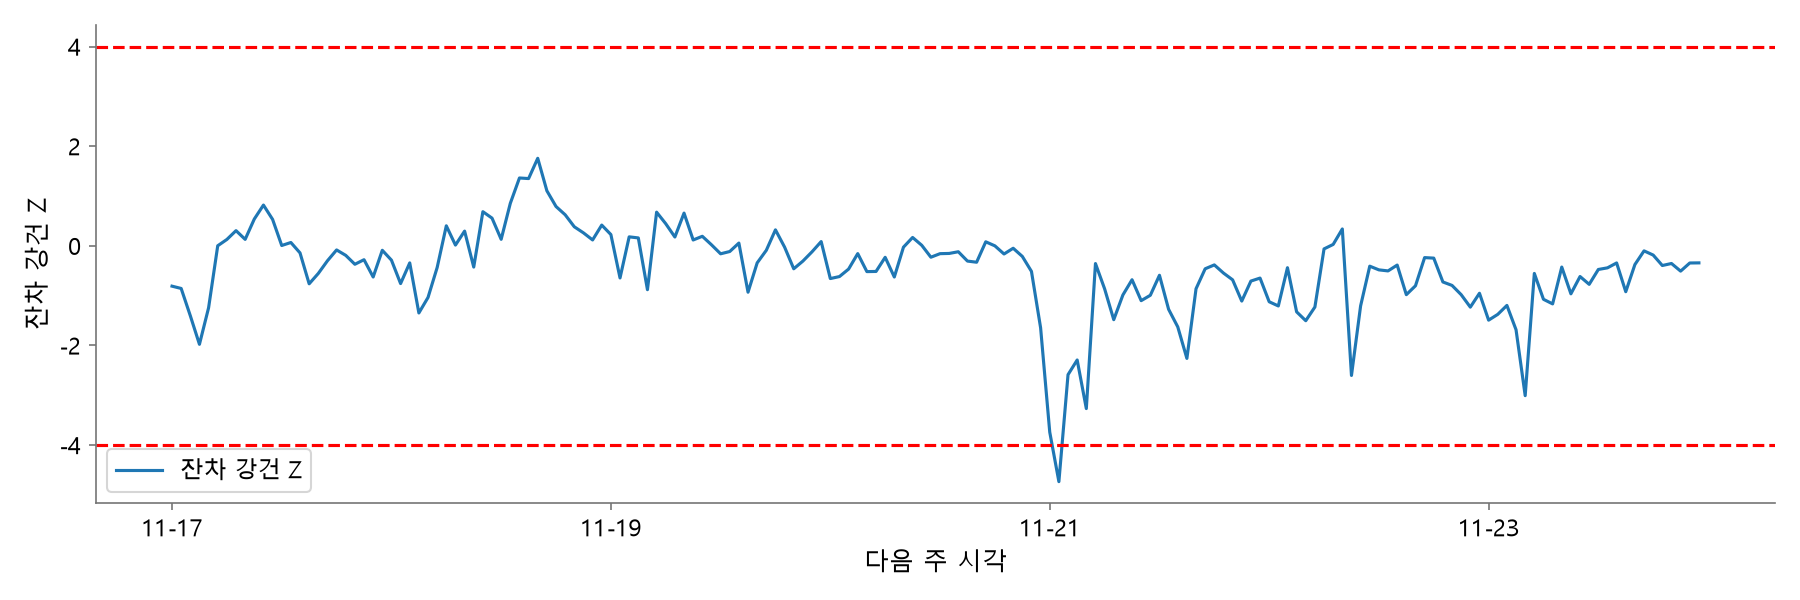

,예측,강건Z,이상
시각,,,
2018-11-17 00:00:00,754.0,-0.811006,False
2018-11-17 01:00:00,679.0,-0.857177,False
2018-11-17 02:00:00,568.0,-1.404061,False
2018-11-17 03:00:00,372.0,-1.978533,False
2018-11-17 04:00:00,223.0,-1.245231,False
...,...,...,...
2018-11-23 19:00:00,1303.0,-0.396441,False
2018-11-23 20:00:00,995.0,-0.355986,False
2018-11-23 21:00:00,907.0,-0.509352,False


In [13]:
# 미션 2 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → AI 튜터에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
# 예시 프롬프트도 아래 따옴표 안에 붙여 넣어야 채점됩니다. 대화창에만 붙이면 잠깁니다
PROMPT = """
아래 변수들 코드 짤때 그대로 사용해줘(필수!)
쓸 수 있는 이름 : plan · CNT · DEM · RESID · HOUR · LABEL · IN_BASE · MED_H · MAD_H · ALERTS · datefmt

운영팀 요청으로 다음 주 168시각마다 몇 대를 내고, 어느 시각을 사람이 다시 볼지 한장으로 적으려고해
아래는 코드 실행 시 추출되어야 하는 것들이야
1. 예측 열: 1주일 전 같은 시각의 보정 수요로 DEM.shift(168)에서 plan의 168 시각을 골라 plan의 열로 둬
2. 임계값별 기준 구간 하루 오탐 수: 단위 건, 소수 둘째자리까지, 기준 구간에서 라벨이 없는 시각의 강건 z 절댓값이 임계값을 넘은 시각 수를 기준 구잔의 날짜 수로 나눠
3. 이상열: 고른 임계값으로 168시각의 강건 z를 계산해, 절댓값이 임계값을 넘으면 참으로 적어줘
4. 그래프(종류 자유)
가로축: 다음 주 시각
세로축: 잔차 강건 z
3번의 강건 z의 선 하나와 고른 임계값의 임계선을 기재해줘

"""
# --- 여기부터 AI 코드 ---
# 1. 예측 열
plan["예측"] = DEM.shift(168).loc[plan.index]

# 2. 임계값별 기준 구간 하루 오탐 수
n_days = IN_BASE.sum() / 24
base_mask = IN_BASE & ~LABEL & RESID.notna()
med_base = HOUR.map(MED_H)
mad_base = HOUR.map(MAD_H)
z_base = (0.6745 * (RESID - med_base) / mad_base)[base_mask]

fp_by_threshold = {}
for th in ALERTS:
    fp = (z_base.abs() > th).sum() / n_days
    fp_by_threshold[th] = fp
    print(f"임계값 {th} 에서 기준 구간 하루 오탐 수 = {fp:.2f} 건")

# 내가 정한 상한: 하루 오탐 2건 이하를 만족하는 가장 작은 임계값
CAP = 2
ALERT = min(th for th in ALERTS if fp_by_threshold[th] <= CAP)
print(f"선택한 임계값 ALERT = {ALERT} (하루 오탐 상한 {CAP}건 기준)")

# 3. 이상 열
hours = plan.index.hour
med_plan = MED_H.loc[hours].values
mad_plan = MAD_H.loc[hours].values
plan["강건Z"] = 0.6745 * (RESID.loc[plan.index].values - med_plan) / mad_plan
plan["이상"] = plan["강건Z"].abs() > ALERT

# 4. 그래프
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plan.index, plan["강건Z"], label="잔차 강건 Z")
ax.axhline(ALERT, color="red", linestyle="--")
ax.axhline(-ALERT, color="red", linestyle="--")
ax.set_xlabel("다음 주 시각")
ax.set_ylabel("잔차 강건 Z")
datefmt(ax)
ax.legend()
plt.show()

plan